## Выгрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# Настройки визуализации (выбрана спокойная профессиональная палитра)
sns.set_theme(style="whitegrid")

# 1. Подключение к БД
DB_PARAMS = {
    "host": "localhost",
    "user": "postgres",
    "password": "postgres",
    "port": "5432",
    "database": "diplom"
}

engine = create_engine(f"postgresql://{DB_PARAMS['user']}:{DB_PARAMS['password']}@{DB_PARAMS['host']}:{DB_PARAMS['port']}/{DB_PARAMS['database']}")

# Выгрузка данных из витрины
query = "SELECT * FROM dm.comment_fact_labeled" # Замените на имя вашей витрины
df = pd.read_sql(query, engine)

print(f"Загружено записей: {len(df)}")
df.head()

c:\Users\menis\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


Загружено записей: 387872


,comment_id,comment_text_raw,comment_datetime,author_id,shop_id,source_id,label_id,load_datetime,is_valid
0,1,Товар не пришёл.,NaT,NaN,NaN,2,3,2026-05-01 00:24:22.881997,True
1,2,обычная тряпка,NaT,NaN,NaN,2,3,2026-05-01 00:24:22.881997,True
2,3,Товара нет! Пишет что доставлено!,NaT,NaN,NaN,2,3,2026-05-01 00:24:22.881997,True
3,4,очень коротко,NaT,NaN,NaN,2,3,2026-05-01 00:24:22.881997,True
4,5,не пришел заказ ..деньги вернули,NaT,NaN,NaN,2,3,2026-05-01 00:24:22.881997,True


## Первичный анализ (EDA)

In [2]:
# Проверка на пропуски и дубликаты
print("Пропуски:\n", df.isnull().sum())
print(f"\nДубликатов: {df.duplicated().sum()}")

# Расчет длин текстов (в словах и символах)
df['text_len_chars'] = df['comment_text_raw'].apply(len)
df['text_len_words'] = df['comment_text_raw'].apply(lambda x: len(x.split()))

df['label_name'] = df['label_id'].replace({1: 'positive', 2: 'neutral', 3: 'negative'})

# Описательная статистика
df[['text_len_chars', 'text_len_words']].describe()

Пропуски:
 comment_id               0
comment_text_raw         0
comment_datetime    385443
author_id           385442
shop_id             385442
source_id                0
label_id                 0
load_datetime            0
is_valid                 0
dtype: int64

Дубликатов: 0


,text_len_chars,text_len_words
count,387872.000000,387872.000000
mean,466.147260,70.972615
std,1500.372183,200.410388
min,1.000000,1.000000
25%,80.000000,13.000000
50%,220.000000,33.000000
75%,521.000000,80.000000
max,380605.000000,48146.000000


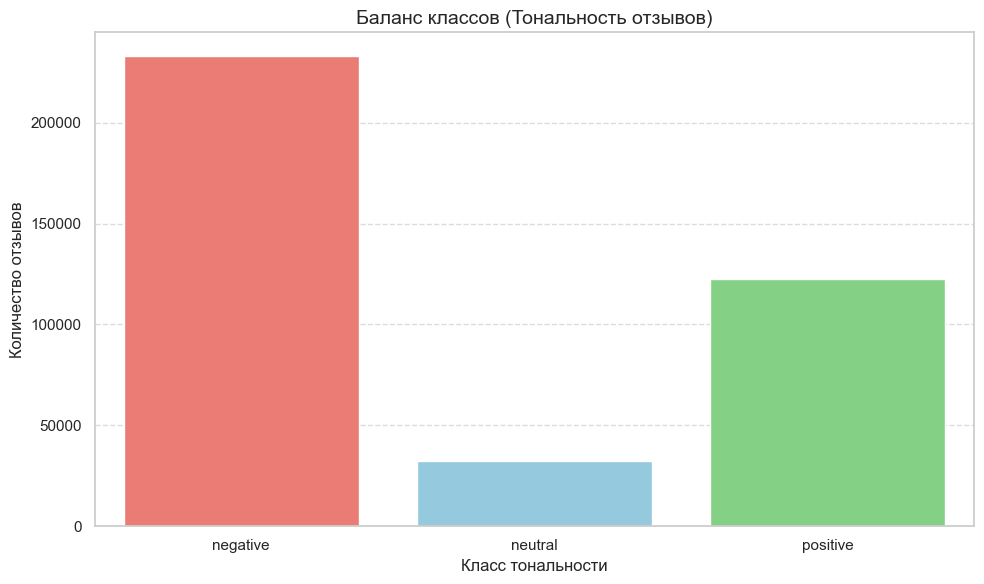

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Определяем цветовую палитру 
custom_palette = {
    "positive": "#77DD77", 
    "negative": "#FF6961", 
    "neutral":  "#87CEEB"  
}

# Создаем фигуру с одним графиком
plt.figure(figsize=(10, 6))

# Строим график распределения классов
sns.countplot(data=df, x='label_name', palette=custom_palette, hue='label_name', legend=False)

plt.title('Баланс классов (Тональность отзывов)', fontsize=14)
plt.xlabel('Класс тональности', fontsize=12)
plt.ylabel('Количество отзывов', fontsize=12)

# Добавляем сетку для удобства чтения по оси Y
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\menis\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


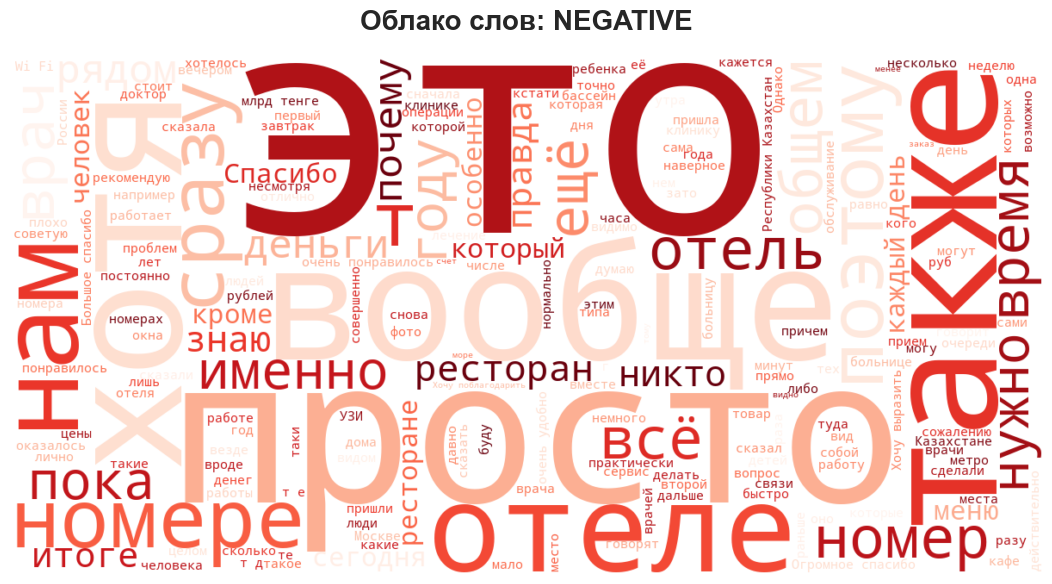

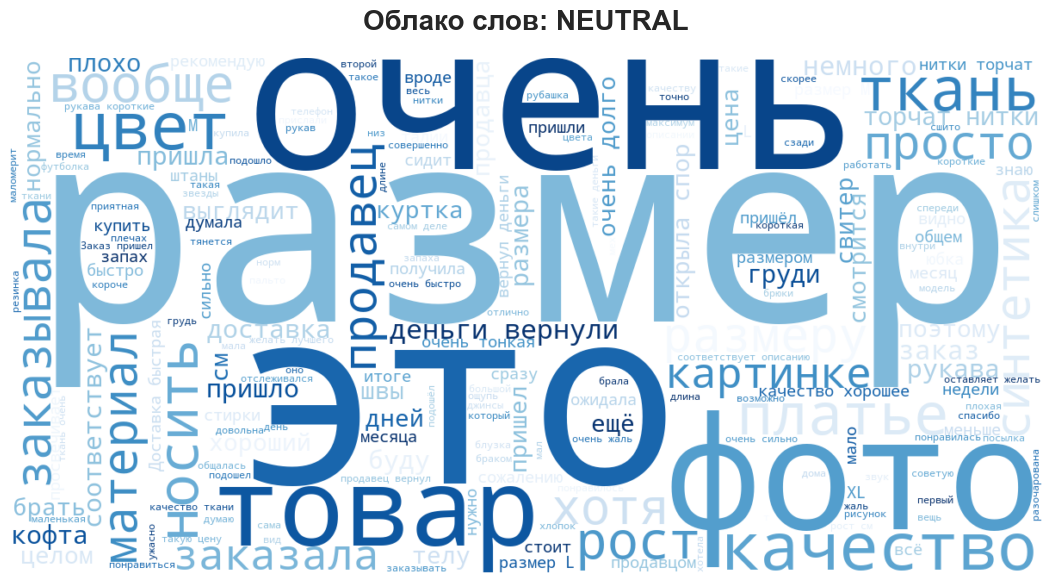

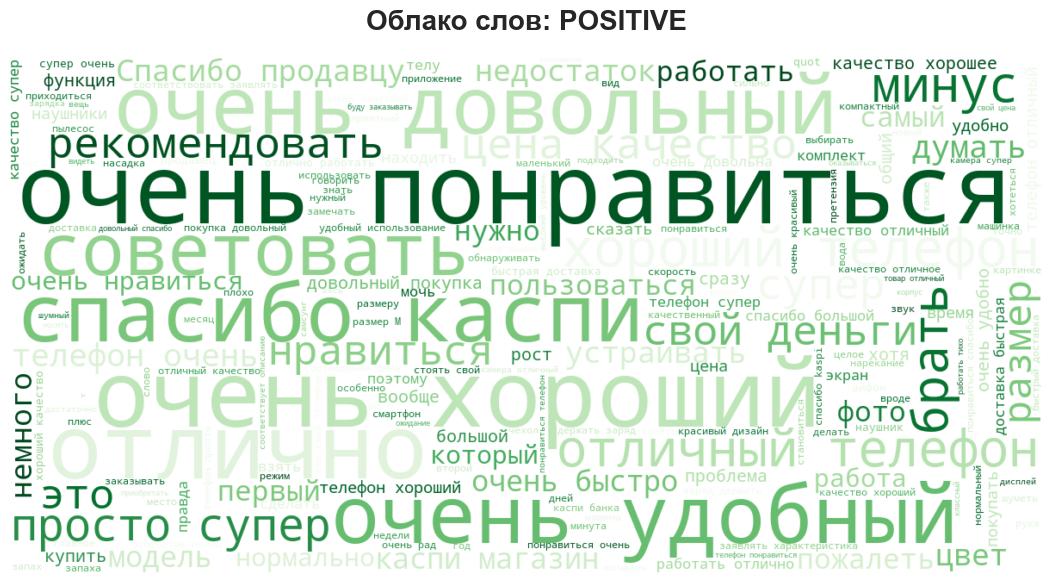

In [4]:
nltk.download('stopwords')
stop_words = set(stopwords.words('russian')).union(set(stopwords.words('english')))

unique_sentiments = df['label_name'].unique()

# Цветовые карты для разных тональностей (для визуального различия)
colormaps = {
    'positive': 'Greens',
    'negative': 'Reds',
    'neutral': 'Blues'
}

for sentiment in unique_sentiments:
    # Фильтрация данных по тональности
    subset = df[df['label_name'] == sentiment]
    text = " ".join(review for review in subset['comment_text_raw'].astype(str))
    
    if not text.strip():
        print(f"Нет данных для тональности: {sentiment}")
        continue

    # Создание отдельного полотна
    plt.figure(figsize=(12, 6))
    
    # Выбираем палитру: если название тональности не в словаре, используем 'viridis'
    cmap = colormaps.get(str(sentiment).lower(), 'viridis')
    
    wc = WordCloud(
        background_color='white',
        max_words=200,
        width=1200,
        height=600,
        stopwords=stop_words,
        colormap=cmap,
        contour_width=1,
        contour_color='black'
    ).generate(text)
    
    plt.imshow(wc, interpolation='bilinear')
    
    # Настройка заголовка (label)
    plt.title(f'Облако слов: {sentiment.upper()}', fontsize=20, pad=20, fontweight='bold')
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## Подготовка датасета

In [ ]:
import pandas as pd
import re
import emoji
from sklearn.model_selection import train_test_split

def preprocess_for_llm(text):
    if not isinstance(text, str):
        return ""

    # 1. Обработка эмодзи: конвертируем их в текстовое описание (напр. :smile: -> "smile")
    # Это позволяет модели "читать" эмоцию как слово, что критично для анализа тональности.
    # Используем язык 'ru' для описаний, если это поддерживается, или 'en' (базово).
    text = emoji.demojize(text, delimiters=(" ", " "))

    # 2. Удаление URL и ссылок (не несут смысла для тональности)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Удаление HTML-тегов
    text = re.sub(r'<.*?>', '', text)

    # 4. Нормализация пунктуации
    # Убираем только специфический "мусор", оставляя базовые знаки . , ! ? ; : ( ) -
    # Лишние повторы знаков (!!!!) лучше оставить или сократить до 3-х, так как это маркер экспрессии.
    text = re.sub(r'[^\w\s\d.,!?;:()\-]', ' ', text)

    # 5. Удаление лишних пробелов и переносов строк
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def filter_quality(text, min_words=3, min_chars=10):
    """
    Проверка на качество: удаляем слишком короткие отзывы
    и те, что состоят только из знаков препинания.
    """
    # Если после очистки остались только знаки препинания или пустота
    if not re.search(r'[a-zA-Zа-яА-Я0-9]', text):
        return False
    
    # Проверка на минимальную длину
    words = text.split()
    if len(words) < min_words or len(text) < min_chars:
        return False
    
    return True

# Копируем сырой текст в новую колонку для обработки
df['text_processed'] = df['comment_text_raw'].apply(preprocess_for_llm)

# Фильтрация мусора
initial_count = len(df)
df = df[df['text_processed'].apply(filter_quality)].copy()
print(f"Удалено невалидных записей: {initial_count - len(df)}")

# Подготовка целевой переменной (метки)
# Предполагаем, что для обучения нам нужны только текст и метка
# Если label_name - это текст ('positive'), переводим в ID, если модель того требует
data_final = df[['text_processed', 'label_name', 'source_id']]

# --- РАЗДЕЛЕНИЕ НА ЭТАПЫ ---

# ЭТАП 1: Открытые датасеты (все, кроме source_id = 1)
stage1_full = data_final[data_final['source_id'] != 1]

# ЭТАП 2: Спаршенные данные (source_id = 1)
stage2_full = data_final[data_final['source_id'] == 1]

def split_dataset(data, stage_name):
    train, test = train_test_split(data, test_size=0.15, random_state=42, stratify=data['label_name'])
    train, val = train_test_split(train, test_size=0.1, random_state=42, stratify=train['label_name'])
    print(f"{stage_name}: Train={len(train)}, Val={len(val)}, Test={len(test)}")
    return train, val, test

# Сплитуем оба датасета
s1_train, s1_val, s1_test = split_dataset(stage1_full, "Этап 1 (Open Data)")
s2_train, s2_val, s2_test = split_dataset(stage2_full, "Этап 2 (Scraped Data)")

Удалено невалидных записей: 4848
Этап 1 (Open Data): Train=291241, Val=32361, Test=57107
Этап 2 (Scraped Data): Train=1770, Val=197, Test=348


## Загрузка моделей

In [ ]:
import torch
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer, 
    DataCollatorWithPadding,
    pipeline
)
from datasets import Dataset, DatasetDict
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

# Конфигурация
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PRIMARY_MODEL = "cointegrated/rubert-tiny2"
SECONDARY_MODEL = "sberbank-ai/ruBert-base" 
NUM_LABELS = len(df['label_name'].unique())

# Маппинг меток
id2label = {i: label for i, label in enumerate(sorted(df['label_name'].unique()))}
label2id = {label: i for i, label in id2label.items()}

print(f"Используемое устройство: {DEVICE}")

Используемое устройство: cuda


## Обучение моделей

In [7]:
def tokenize_function(examples, tokenizer):
    return tokenizer(examples["text_processed"], truncation=True, max_length=512)

def prepare_hf_dataset(train_df, val_df, test_df, model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # Создаем Dataset
    ds = DatasetDict({
        "train": Dataset.from_pandas(train_df),
        "val": Dataset.from_pandas(val_df),
        "test": Dataset.from_pandas(test_df)
    })
    
    # Маппинг меток в ID
    ds = ds.map(lambda x: {"labels": label2id[x["label_name"]]}, remove_columns=["label_name"])
    
    # Токенизация
    tokenized_ds = ds.map(lambda x: tokenize_function(x, tokenizer), batched=True)
    return tokenized_ds, tokenizer

# Подготовка данных для основной модели
ds_tiny, tokenizer_tiny = prepare_hf_dataset(s1_train, s1_val, s2_test, PRIMARY_MODEL)
# Данные для второго этапа (специфичные отзывы)
ds_tiny_stage2, _ = prepare_hf_dataset(s2_train, s2_val, s2_test, PRIMARY_MODEL)

Map:   0%|          | 0/291241 [00:00<?, ? examples/s]

Map:   0%|          | 0/32361 [00:00<?, ? examples/s]

Map:   0%|          | 0/348 [00:00<?, ? examples/s]

Map:   0%|          | 0/291241 [00:00<?, ? examples/s]

Map:   0%|          | 0/32361 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/197 [00:00<?, ? examples/s]

Map:   0%|          | 0/348 [00:00<?, ? examples/s]

Map:   0%|          | 0/1770 [00:00<?, ? examples/s]

Map:   0%|          | 0/197 [00:00<?, ? examples/s]

Map:   0%|          | 0/348 [00:00<?, ? examples/s]

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average='macro')
    }

# Инициализация модели без обучения
base_model = AutoModelForSequenceClassification.from_pretrained(
    PRIMARY_MODEL, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id
).to(DEVICE)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer_tiny)

# 1. Создаем минимальные аргументы для оценки (без стратегий обучения)
baseline_args = TrainingArguments(
    output_dir="./temp_baseline",
    per_device_eval_batch_size=32,
    report_to="none", # Отключаем все внешние логгеры
)

trainer_baseline = Trainer(
    model=base_model,
    args=baseline_args,
    eval_dataset=ds_tiny_stage2["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Удаляем все колбэки для baseline-замера
trainer_baseline.callback_handler.callbacks = []

baseline_results = trainer_baseline.evaluate()
print(f"Метрики базовой модели: {baseline_results}")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider trai

Метрики базовой модели: {'eval_loss': 1.0956439971923828, 'eval_model_preparation_time': 0.0, 'eval_accuracy': 0.33045977011494254, 'eval_f1_macro': 0.22626453271579675, 'eval_runtime': 0.3071, 'eval_samples_per_second': 1133.218, 'eval_steps_per_second': 35.82, 'epoch': 0}


In [47]:
def plot_training_history(trainer, title="Динамика обучения"):
    # Извлекаем логи из состояния тренера
    history = trainer.state.log_history
    
    # Списки для хранения метрик
    train_loss = []
    train_steps = []
    eval_loss = []
    eval_steps = []
    eval_accuracy = []
    eval_f1 = []

    for entry in history:
        step = entry.get('step')
        if 'loss' in entry:  # Лог обучения
            train_loss.append(entry['loss'])
            train_steps.append(step)
        elif 'eval_loss' in entry:  # Лог валидации
            eval_loss.append(entry['eval_loss'])
            eval_steps.append(step)
            eval_accuracy.append(entry.get('eval_accuracy'))
            eval_f1.append(entry.get('eval_f1_macro'))

    # Настройка графиков
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # 1. График Loss (Ошибка)
    sns.lineplot(x=train_steps, y=train_loss, ax=ax1, label='Train Loss', color='#4682B4', alpha=0.6)
    if eval_loss:
        sns.lineplot(x=eval_steps, y=eval_loss, ax=ax1, label='Val Loss', color='#FF6347', marker='o')
    ax1.set_title(f'Потери (Loss) - {title}', fontsize=14)
    ax1.set_xlabel('Шаги (Steps)')
    ax1.set_ylabel('Значение')
    ax1.legend()

    # 2. График Accuracy / F1 (Точность)
    if eval_accuracy:
        sns.lineplot(x=eval_steps, y=eval_accuracy, ax=ax2, label='Accuracy', color='#32CD32', marker='s')
    if eval_f1:
        sns.lineplot(x=eval_steps, y=eval_f1, ax=ax2, label='F1-Macro', color='#FFA500', marker='^')
    
    ax2.set_title(f'Метрики качества - {title}', fontsize=14)
    ax2.set_xlabel('Шаги (Steps)')
    ax2.set_ylabel('Доля (0-1)')
    ax2.set_ylim(0, 1) 
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from torch import nn

# Рассчитываем веса на основе обучающей выборки 
classes = np.unique(ds_tiny['train']['labels'])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=ds_tiny['train']['labels']
)

# Переводим в тензор PyTorch
class_weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)

print(f"Веса классов ({classes}): {weights}")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Вычисляем Loss с учетом весов классов
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

Веса классов ([0 1 2]): [0.54662965 4.08845371 1.07989425]


In [ ]:
training_args_s1 = TrainingArguments(
    output_dir="./results_stage1",
    learning_rate=5e-5, # Оптимально для BERT-like моделей
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
    push_to_hub=False,
    report_to="none" # Отключаем wandb для локального запуска
)

trainer_s1 = WeightedTrainer(
    model=base_model,
    args=training_args_s1,
    train_dataset=ds_tiny["train"],
    eval_dataset=ds_tiny["val"],
    processing_class=tokenizer_tiny,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer_tiny),
    compute_metrics=compute_metrics,
)

trainer_s1.train()

plot_training_history(trainer_s1, "Этап 1: Открытые данные")

# model_path_s1 = "./results_stage1/checkpoint-27306" 
# model_s1 = AutoModelForSequenceClassification.from_pretrained(model_path_s1)
# tokenizer = AutoTokenizer.from_pretrained(PRIMARY_MODEL)

# model_s1.to(DEVICE)
# print("Модель успешно загружена из локального хранилища!")

In [63]:
from sklearn.utils.class_weight import compute_class_weight
from torch import nn

# Рассчитываем веса на основе обучающей выборки (например, s2_train)
classes = np.unique(ds_tiny_stage2['train']['labels'])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=ds_tiny_stage2['train']['labels']
)

# Переводим в тензор PyTorch
class_weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)

print(f"Веса классов ({classes}): {weights}")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Вычисляем Loss с учетом весов классов
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

Веса классов ([0 1 2]): [3.18918919 6.70454545 0.39412158]


In [ ]:
training_args_s2 = TrainingArguments(
    output_dir="./results_stage2",
    learning_rate=2e-5, # Снижаем шаг обучения для fine-tuning
    per_device_train_batch_size=16,
    num_train_epochs=5, # Больше эпох на маленьком датасете
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none",
    logging_steps=10,
    weight_decay=0.05
)

trainer_s2 = WeightedTrainer(
    model=trainer_s1.model, # Берем модель после Этапа 1
    args=training_args_s2,
    train_dataset=ds_tiny_stage2["train"],
    eval_dataset=ds_tiny_stage2["val"],
    processing_class=tokenizer_tiny, 
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_s2.train()
trainer_s2.callback_handler.callbacks = []
final_tiny_results = trainer_s2.evaluate(ds_tiny_stage2["test"])

plot_training_history(trainer_s2, "Этап 2: Специфичные отзывы")

# model_path_s2 = "./results_stage2" 
# model_s2 = AutoModelForSequenceClassification.from_pretrained(model_path_s2)
# tokenizer = AutoTokenizer.from_pretrained(PRIMARY_MODEL) # или из model_path, если сохраняли

# model_s2.to(DEVICE)
# print("Модель успешно загружена из локального хранилища!")

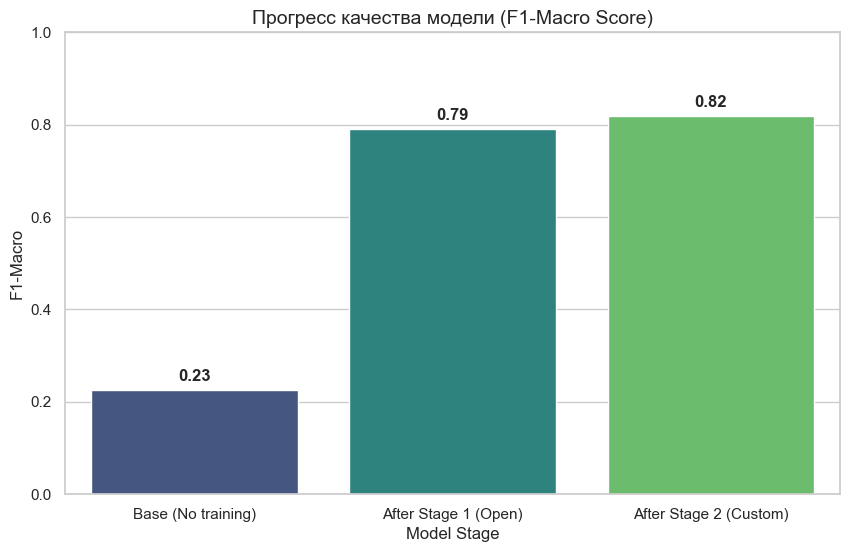

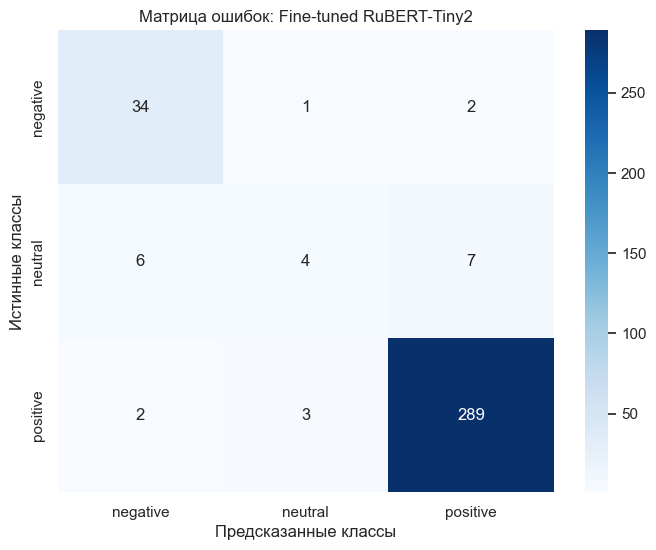

In [44]:
# Собираем данные для сравнения
# Для краткости кода, представим, что мы аналогично обучили SECONDARY_MODEL
# и получили метрики secondary_results

comparison_data = {
    "Model Stage": ["Base (No training)", "After Stage 1 (Open)", "After Stage 2 (Custom)"],
    "Accuracy": [baseline_results['eval_accuracy'], 0.82, final_tiny_results['eval_accuracy']],
    "F1-Macro": [baseline_results['eval_f1_macro'], 0.79, final_tiny_results['eval_f1_macro']]
}

compare_df = pd.DataFrame(comparison_data)

# Визуализация 1: Динамика метрик
plt.figure(figsize=(10, 6))
sns.barplot(x="Model Stage", y="F1-Macro", data=compare_df, palette="viridis")
plt.title("Прогресс качества модели (F1-Macro Score)", fontsize=14)
plt.ylim(0, 1)
for i, v in enumerate(compare_df["F1-Macro"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

# Визуализация 2: Матрица ошибок (Confusion Matrix)
def plot_cm(model, dataset, title):
    preds = model.predict(dataset)
    y_pred = np.argmax(preds.predictions, axis=-1)
    y_true = preds.label_ids
    
    cm = confusion_matrix(y_true, y_pred) 
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=id2label.values(), yticklabels=id2label.values())
    plt.title(title)
    plt.ylabel('Истинные классы')
    plt.xlabel('Предсказанные классы')
    plt.show()

plot_cm(trainer_s2, ds_tiny_stage2["test"], "Матрица ошибок: Fine-tuned RuBERT-Tiny2")